In [31]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)

SEED = 42
DATA_PATH = Path("Credito.xlsx")
MODEL_PATH = Path("model_credito.joblib")
METADATA_PATH = Path("model_credito_metadata.json")
TARGET_COL = "Credito"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontro el archivo de datos: {DATA_PATH.resolve()}")

print("Configuracion lista.")
print(f"Archivo de datos: {DATA_PATH.resolve()}")

Configuracion lista.
Archivo de datos: C:\GitHub\Analitica-Negocios\Semana_1_Proyecto_1\Credito.xlsx


In [32]:
df = pd.read_excel(DATA_PATH, sheet_name="DATA")

print("Shape:", df.shape)
print("Columnas:", list(df.columns))
df.head()

Shape: (750, 8)
Columnas: ['Credito', 'Edad', 'Tarjetas', 'Deuda', 'Saldo', 'CrediScore', 'Años_empleo', 'Ingresos']


,Credito,Edad,Tarjetas,Deuda,Saldo,CrediScore,Años_empleo,Ingresos
0,Si,31.80,1,7500,26726,5,2.710,2547
1,No,43.54,3,3165,0,0,3.750,801
2,No,45.33,1,1000,0,0,0.125,806
3,No,60.79,1,2500,0,0,1.000,811
4,Si,44.33,3,500,0,0,5.000,2548


In [33]:
if TARGET_COL not in df.columns:
    raise ValueError(f"La columna objetivo '{TARGET_COL}' no existe.")

missing_by_col = df.isna().sum().sort_values(ascending=False)
print("Valores faltantes por columna:")
print(missing_by_col)

X = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].copy()

# Estandariza etiquetas binarias a 0/1 sin asumir el tipo original.
if y_raw.nunique() != 2:
    raise ValueError(f"Se esperaba un target binario y se encontraron {y_raw.nunique()} clases.")

y = pd.Series(pd.Categorical(y_raw).codes, index=y_raw.index, name=TARGET_COL)
label_mapping = dict(enumerate(pd.Categorical(y_raw).categories))

print("Distribucion de clases (codificada):")
print(y.value_counts(normalize=True).rename("proporcion"))
print("Mapa de clases:", label_mapping)

Valores faltantes por columna:
Credito        0
Edad           0
Tarjetas       0
Deuda          0
Saldo          0
CrediScore     0
Años_empleo    0
Ingresos       0
dtype: int64
Distribucion de clases (codificada):
Credito
0    0.554667
1    0.445333
Name: proporcion, dtype: float64
Mapa de clases: {0: 'No', 1: 'Si'}


In [34]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print("Features numericas:", len(numeric_features))
print("Features categoricas:", len(categorical_features))
print("Train/Test:", X_train.shape, X_test.shape)

Features numericas: 7
Features categoricas: 0
Train/Test: (600, 7) (150, 7)


In [35]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=8)),
    ]
)

baseline_model.fit(X_train, y_train)
print("Baseline entrenado (KNN).")

Baseline entrenado (KNN).


In [36]:
y_pred_baseline = baseline_model.predict(X_test)

if hasattr(baseline_model, "predict_proba"):
    y_score_baseline = baseline_model.predict_proba(X_test)[:, 1]
else:
    y_score_baseline = baseline_model.decision_function(X_test)

baseline_metrics = {
    "roc_auc": roc_auc_score(y_test, y_score_baseline),
    "f1": f1_score(y_test, y_pred_baseline),
    "recall": recall_score(y_test, y_pred_baseline),
    "precision": precision_score(y_test, y_pred_baseline),
    "accuracy": accuracy_score(y_test, y_pred_baseline),
}

pd.Series(baseline_metrics).sort_index()

accuracy     0.913333
f1           0.900763
precision    0.921875
recall       0.880597
roc_auc      0.956123
dtype: float64

In [37]:
print("Reporte baseline (KNN):")
print(classification_report(y_test, y_pred_baseline, digits=4))
print("Matriz de confusion:")
print(confusion_matrix(y_test, y_pred_baseline))

Reporte baseline (KNN):
              precision    recall  f1-score   support

           0     0.9070    0.9398    0.9231        83
           1     0.9219    0.8806    0.9008        67

    accuracy                         0.9133       150
   macro avg     0.9144    0.9102    0.9119       150
weighted avg     0.9136    0.9133    0.9131       150

Matriz de confusion:
[[78  5]
 [ 8 59]]


In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search_spaces = {
    "knn": {
        "model": Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", KNeighborsClassifier()),
            ]
        ),
        "params": {
            "classifier__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
            "classifier__weights": ["uniform", "distance"],
            "classifier__p": [1, 2],
        },
        "n_iter": 12,
    },
    "svc": {
        "model": Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", SVC(probability=True, random_state=SEED)),
            ]
        ),
        "params": {
            "classifier__C": np.logspace(-2, 2, 20),
            "classifier__gamma": np.logspace(-4, 0, 20),
            "classifier__kernel": ["rbf"],
        },
        "n_iter": 20,
    },
    "logreg": {
        "model": Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", LogisticRegression(max_iter=3000, random_state=SEED)),
            ]
        ),
        "params": {
            "classifier__C": np.logspace(-3, 2, 20),
            "classifier__solver": ["lbfgs", "liblinear"],
            "classifier__class_weight": [None, "balanced"],
        },
        "n_iter": 20,
    },
}

print("Espacios de busqueda listos:", list(search_spaces.keys()))

Espacios de busqueda listos: ['knn', 'svc', 'logreg']


In [39]:
search_results = []
best_estimators = {}

for name, cfg in search_spaces.items():
    print(f"\nBuscando hiperparametros para: {name}")
    search = RandomizedSearchCV(
        estimator=cfg["model"],
        param_distributions=cfg["params"],
        n_iter=cfg["n_iter"],
        scoring={
            "roc_auc": "roc_auc",
            "f1": "f1",
            "recall": "recall",
            "precision": "precision",
            "accuracy": "accuracy",
        },
        refit="roc_auc",
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )

    search.fit(X_train, y_train)
    best_estimators[name] = search.best_estimator_

    search_results.append(
        {
            "model": name,
            "best_cv_roc_auc": search.best_score_,
            "best_params": search.best_params_,
        }
    )

results_df = pd.DataFrame(search_results).sort_values("best_cv_roc_auc", ascending=False)
results_df


Buscando hiperparametros para: knn

Buscando hiperparametros para: svc

Buscando hiperparametros para: logreg


,model,best_cv_roc_auc,best_params
2,logreg,0.967437,"{'classifier__solver': 'lbfgs', 'classifier__c..."
1,svc,0.966875,"{'classifier__kernel': 'rbf', 'classifier__gam..."
0,knn,0.963012,"{'classifier__weights': 'uniform', 'classifier..."


In [40]:
best_model_name = results_df.iloc[0]["model"]
best_model = best_estimators[best_model_name]

print("Mejor modelo por CV ROC-AUC:", best_model_name)
print("Mejores parametros:")
print(results_df.iloc[0]["best_params"])

Mejor modelo por CV ROC-AUC: logreg
Mejores parametros:
{'classifier__solver': 'lbfgs', 'classifier__class_weight': None, 'classifier__C': np.float64(29.763514416313193)}


In [41]:
y_pred = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)

final_metrics = {
    "roc_auc": roc_auc_score(y_test, y_score),
    "f1": f1_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "accuracy": accuracy_score(y_test, y_pred),
}

metrics_df = pd.DataFrame(
    [
        {"stage": "baseline_knn", **baseline_metrics},
        {"stage": f"best_{best_model_name}", **final_metrics},
    ]
).set_index("stage")

metrics_df

,roc_auc,f1,recall,precision,accuracy
stage,,,,,
baseline_knn,0.956123,0.900763,0.880597,0.921875,0.913333
best_logreg,0.960079,0.932331,0.925373,0.939394,0.940000


In [42]:
print("Reporte final (hold-out):")
print(classification_report(y_test, y_pred, digits=4))
print("Matriz de confusion final:")
print(confusion_matrix(y_test, y_pred))

Reporte final (hold-out):
              precision    recall  f1-score   support

           0     0.9405    0.9518    0.9461        83
           1     0.9394    0.9254    0.9323        67

    accuracy                         0.9400       150
   macro avg     0.9399    0.9386    0.9392       150
weighted avg     0.9400    0.9400    0.9400       150

Matriz de confusion final:
[[79  4]
 [ 5 62]]


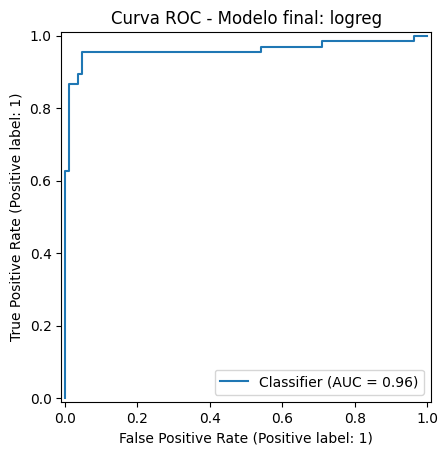

In [43]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, y_score)
plt.title(f"Curva ROC - Modelo final: {best_model_name}")
plt.show()

In [44]:
joblib.dump(best_model, MODEL_PATH)

metadata = {
    "model_file": str(MODEL_PATH),
    "target_column": TARGET_COL,
    "feature_columns": list(X.columns),
    "label_mapping": {str(k): str(v) for k, v in label_mapping.items()},
    "seed": SEED,
    "best_model_name": best_model_name,
    "baseline_metrics": {k: float(v) for k, v in baseline_metrics.items()},
    "final_metrics": {k: float(v) for k, v in final_metrics.items()},
    "best_params": results_df.iloc[0]["best_params"],
    "library_versions": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
}

import sklearn
metadata["library_versions"]["scikit_learn"] = sklearn.__version__

METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Modelo guardado en: {MODEL_PATH.resolve()}")
print(f"Metadata guardada en: {METADATA_PATH.resolve()}")

Modelo guardado en: C:\GitHub\Analitica-Negocios\Semana_1_Proyecto_1\model_credito.joblib
Metadata guardada en: C:\GitHub\Analitica-Negocios\Semana_1_Proyecto_1\model_credito_metadata.json


In [45]:
loaded_model = joblib.load(MODEL_PATH)
loaded_metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

# Prueba de inferencia usando la primera fila del conjunto de test.
sample_input = X_test.iloc[[0]].copy()
sample_pred = loaded_model.predict(sample_input)[0]

if hasattr(loaded_model, "predict_proba"):
    sample_prob = loaded_model.predict_proba(sample_input)[0, 1]
else:
    sample_prob = float("nan")

print("Prediccion de muestra:", int(sample_pred))
print("Probabilidad clase positiva:", round(float(sample_prob), 6))
print("Columnas esperadas por metadata:", loaded_metadata["feature_columns"][:5], "...")

Prediccion de muestra: 1
Probabilidad clase positiva: 0.914444
Columnas esperadas por metadata: ['Edad', 'Tarjetas', 'Deuda', 'Saldo', 'CrediScore'] ...
